In [12]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from notebooks import config

In [ ]:
def get_sat_type(filepath):
    prefix_map = {'L5': 'Landsat-5', 'L7': 'Landsat-7', 'L8': 'Landsat-8',
                    'L9': 'Landsat-9', 'S2': 'Sentinel-2'}
    basename = os.path.basename(filepath)
    return next((name for pfx, name in prefix_map.items() if basename.startswith(pfx)), 'Other')

In [ ]:
def calculate_stats(truth_paths):
    pixels, scenes = Counter(), Counter()
    water = Counter({"Water": 0, "Non-water": 0})

    for path in truth_paths:
        sat = get_sat_type(path)
        scenes[sat] += 1
        
        try:
            with rasterio.open(path) as src:
                pixels[sat] += src.width * src.height
                lbl = src.read(1)
                
                w_count = np.count_nonzero(lbl == 1) 
                water["Water"] += w_count
                water["Non-water"] += lbl.size - w_count
        except Exception as e:
            print(f"[跳过] {os.path.basename(path)}: {e}")

    keys = sorted(pixels.keys())
    return {k: pixels[k] for k in keys}, {k: scenes[k] for k in keys}, dict(water)

In [33]:
def plot_charts(pixels, scenes, water):
    plt.rcParams.update({'font.family': 'Arial', 'font.size': 10})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    colors_sat = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974', '#64b5cd']
    colors_wat = ['#3498db', '#95a5a6']
    txt_style = {'color': 'white', 'weight': 'bold'}  
    wdg_style = {'edgecolor': 'white'}                

    # ================= 图(a): 数据集构成 (双环图) =================
    w_out, _, _ = ax1.pie(
        pixels.values(), radius=1.0, colors=colors_sat, startangle=90,
        autopct='%1.1f%%', pctdistance=0.85, 
        textprops={**txt_style, 'size': 9}, wedgeprops={**wdg_style, 'width': 0.3, 'linewidth': 1.5}
    )
    
    total_scenes = sum(scenes.values())
    ax1.pie(
        scenes.values(), radius=0.68, colors=colors_sat, startangle=90,
        autopct=lambda p: f"{int(round(p * total_scenes / 100))}", pctdistance=0.78, 
        textprops={**txt_style, 'size': 9}, wedgeprops={**wdg_style, 'width': 0.3, 'linewidth': 1.5}
    )

    ax1.legend(w_out, pixels.keys(), title="Satellite Platform", loc="center", frameon=False)
    ax1.text(-0.05, 1, "Outer Ring: Pixel Contribution (%)\n\nInner Ring: Scene Count (N)", 
             transform=ax1.transAxes,fontsize=10, fontweight='bold', color='#333333')
    ax1.set_title("(a) Dataset Composition", y=0, fontweight='bold', size=12)

    # ================= 图(b): 水体像素平衡 (单环图) =================
    w_wat, _, _ = ax2.pie(
        water.values(), radius=1.0, colors=colors_wat, startangle=140,
        autopct='%1.1f%%', pctdistance=0.8, 
        textprops={**txt_style, 'size': 11}, wedgeprops={**wdg_style, 'width': 0.4, 'linewidth': 2}
    )

    ax2.legend(w_wat, water.keys(), title="Pixel Class", loc="center", frameon=False)
    ax2.set_title("(b) Global Pixel Class Balance", y=0, fontweight='bold', size=12)
    
    plt.tight_layout()
    plt.savefig('figs\Fig3_Dataset_Stats.png', dpi=300, bbox_inches='tight')
    plt.show()

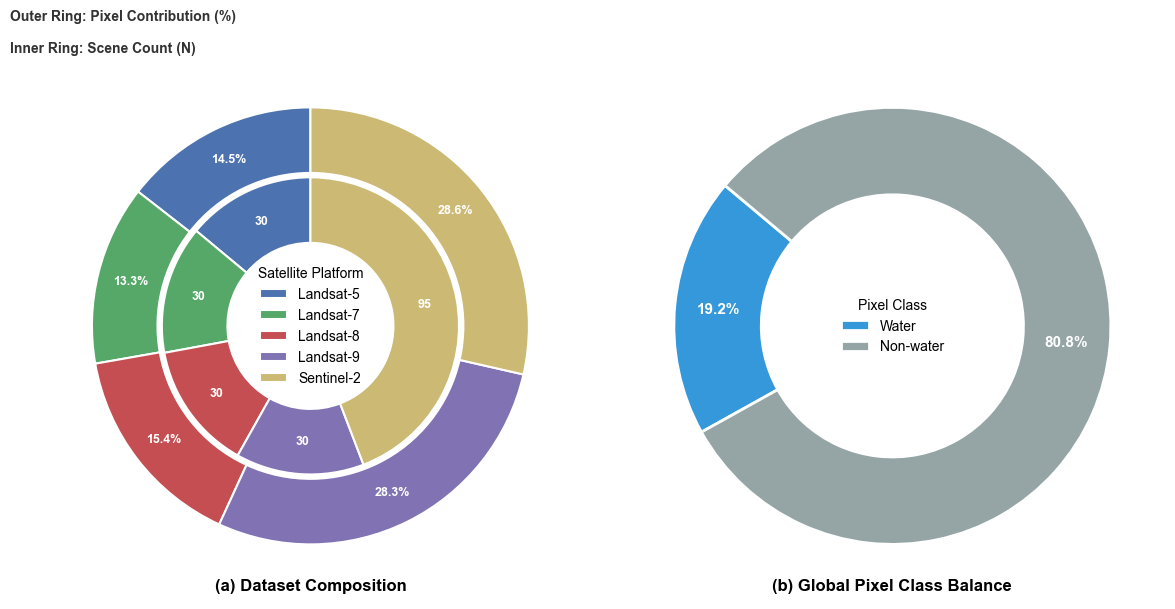

In [34]:
if __name__ == "__main__":
    sat_pixels, sat_scenes, water_counts = calculate_stats(config.paths_truth)
    plot_charts(sat_pixels, sat_scenes, water_counts)